In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mohdtoufeeq","key":"241ecee6b13d6cbb71e9f65a5e8233ec"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic

Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 784M/786M [00:38<00:00, 21.5MB/s]
100% 786M/786M [00:38<00:00, 21.4MB/s]


In [ ]:
!unzip skin-cancer9-classesisic.zip -d /content/dataset

Archive:  skin-cancer9-classesisic.zip
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010512.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010889.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024468.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024470.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024511.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024646.jpg  
  inflating: /content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024654.jpg  
  inflating: /content/d

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score

In [ ]:
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
import os

In [ ]:
X_train = []
Y_train = []
image_size = 150
labels = ['actinic keratosis','basal cell carcinoma','melanoma','nevus','pigmented benign keratosis','seborrheic keratosis','squamous cell carcinoma','vascular lesion']
for i in labels:
    folderPath = os.path.join('/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)


In [ ]:
X_train,Y_train = shuffle(X_train,Y_train,random_state=101)

In [ ]:
X_train.shape, Y_train.shape

((2246, 150, 150, 3), (2246,))

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_train,Y_train,test_size=0.1,random_state=101)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((2021, 150, 150, 3), (225, 150, 150, 3), (2021,), (225,))

In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train.shape, y_test.shape

((2021, 8), (225, 8))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# First Conv Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))  # Lower dropout in early layers

# Second Conv Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

# Third Conv Block
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.4))

# Flatten & Fully Connected Layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))  # Stronger dropout in Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='softmax'))  # 8 classes

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train,y_train,epochs=300,validation_split=0.1)

Epoch 1/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 92s 601ms/step - accuracy: 0.2276 - loss: 21.9086 - val_accuracy: 0.1872 - val_loss: 97.4429
Epoch 2/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.2452 - loss: 12.1007 - val_accuracy: 0.1724 - val_loss: 7.1663
Epoch 3/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.2593 - loss: 8.3739 - val_accuracy: 0.2266 - val_loss: 2.1861
Epoch 4/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.2526 - loss: 5.3155 - val_accuracy: 0.3054 - val_loss: 1.9860
Epoch 5/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.2689 - loss: 3.4914 - val_accuracy: 0.3251 - val_loss: 2.0229
Epoch 6/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.2627 - loss: 2.8026 - val_accuracy: 0.2266 - val_loss: 2.1169
Epoch 7/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.2407 - loss: 2.1964 - val_accuracy: 0.2660 - val_loss: 1.9349
Epoch 8/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.2598 - loss: 2.0661 - 

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


In [ ]:
# Freeze the layers of the base model to prevent them from being trained
base_model.trainable = False

# Add custom layers on top of the base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # To reduce the spatial dimensions to a single value
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')  # Output layer for 8 classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Prepare data generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

train_generator = train_datagen.flow_from_directory(
    '/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Fine-tune: Unfreeze some layers of ResNet50
base_model.trainable = True

# Set the lower layers to be frozen and train only the top layers of ResNet50
for layer in base_model.layers[:100]:  # Freeze first 100 layers of ResNet50
    layer.trainable = False

# Recompile and continue training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Evaluate the model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 5, 5, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           4,617 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,641,417 (94.00 MB)

 Trainable params: 1,053,705 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 1907 images belonging to 9 classes.
Found 14 images belonging to 9 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 55s 687ms/step - accuracy: 0.1810 - loss: 2.2421 - val_accuracy: 0.2143 - val_loss: 2.1722
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 475ms/step - accuracy: 0.1824 - loss: 2.0555 - val_accuracy: 0.1429 - val_loss: 2.2408
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 487ms/step - accuracy: 0.2055 - loss: 2.0672 - val_accuracy: 0.1429 - val_loss: 2.2200
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 492ms/step - accuracy: 0.1957 - loss: 2.0463 - val_accuracy: 0.1429 - val_loss: 2.1856
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 501ms/step - accuracy: 0.1924 - loss: 2.0543 - val_accuracy: 0.2857 - val_loss: 2.1815
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 482ms/step - accuracy: 0.2064 - loss: 2.0379 - val_accuracy: 0.1429 - val_loss: 2.1814
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 478ms/step - accuracy: 0.2014 - loss: 2.0429 - val_accuracy: 0.1429 - val_loss: 2.2340
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 475ms/step - accuracy: 0.1861 - loss: 2.0506 - val_accu

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load Pretrained Model (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the base model initially

# Build Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(8, activation='softmax')  # ✅ Fix output classes to 8
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Data Augmentation (Applied only to training)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15  # ✅ Correctly applied
)

# ✅ Train & Validation Generators (from Training Data Only)
train_generator = train_datagen.flow_from_directory(
    '/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train',  # ✅ Use training folder for validation split
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ✅ Separate Test Generator (NO `validation_split`)
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    '/content/dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ✅ Callbacks for Training Stability
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Train Model (Initial Training)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

# ✅ Fine-Tuning: Unfreeze Some Layers
base_model.trainable = True

# Freeze Only First 100 Layers of ResNet50
for layer in base_model.layers[:100]:
    layer.trainable = False

# ✅ Recompile with Lower Learning Rate for Fine-Tuning
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train Fine-Tuned Model
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

# ✅ Evaluate Model on Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")


Found 1907 images belonging to 9 classes.
Found 332 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 9), output.shape=(None, 8)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

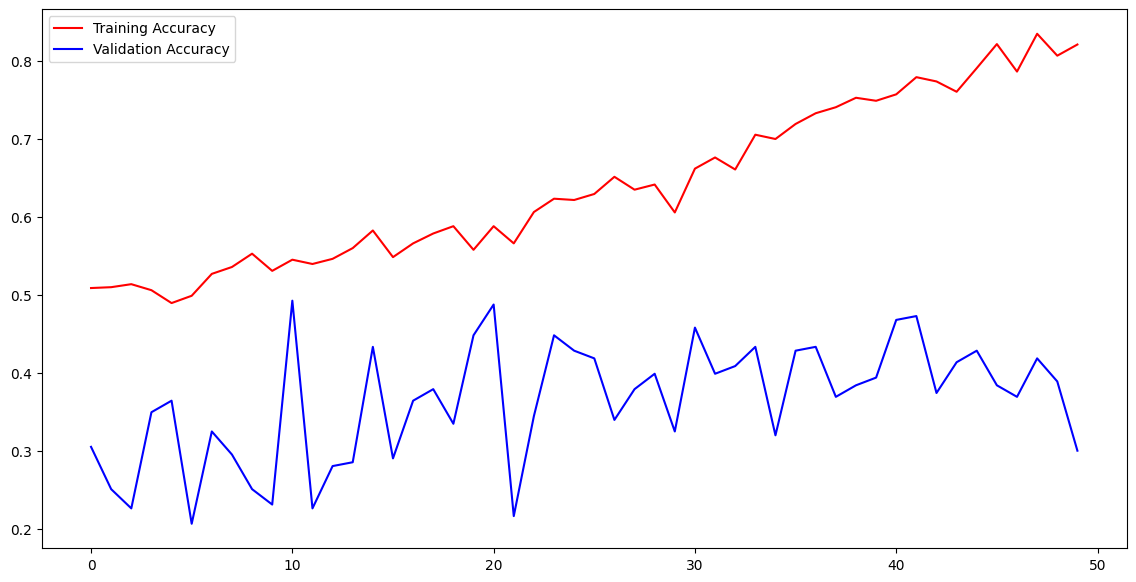

In [ ]:
#model.save('braintumor.h5')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

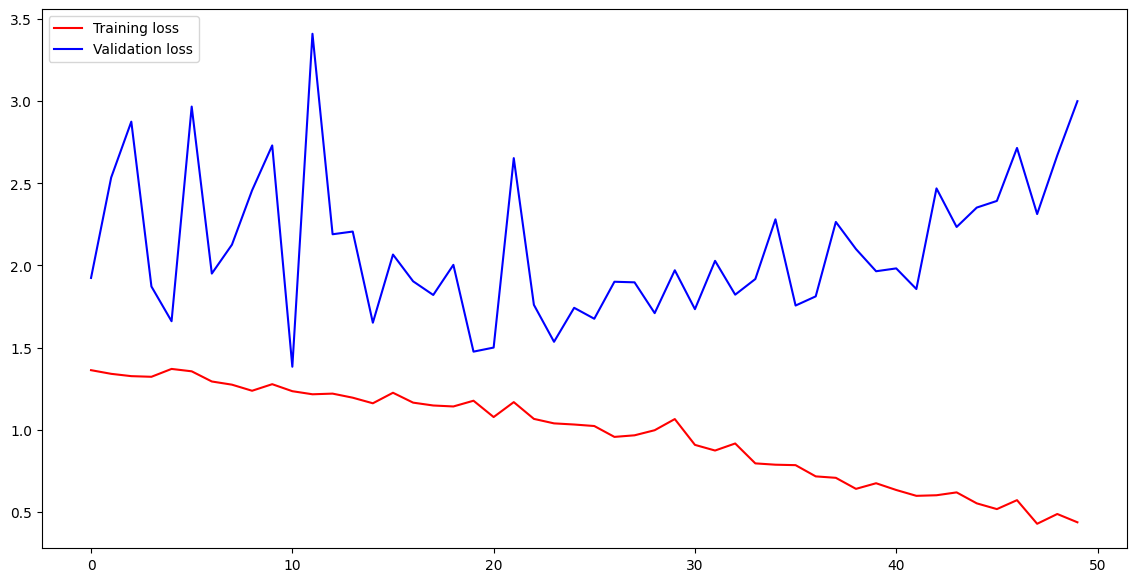

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()